In [1]:
import os
os.chdir('../')

# Analysis for 1PV for the flamelet dataset: effect of the QoI scaling at the decoder's output

In [5]:
from EncoderDecoder.utils import loadData
import matplotlib.pyplot as plt
import logging
logging.disable(logging.CRITICAL)

In [3]:
path_data = "data-files/"
filename = "Tr1_1PV_RMSprop_250_log_s5-AE-date_03Jun2026-hour_18h03_Xu-flamelet-augm"

loader = loadData(filename)
extraVars, PV, PVsource = loader.getManifoldParameters(path_data, "flamelet")

2026-06-10 12:37:30 - INFO - No input scaling


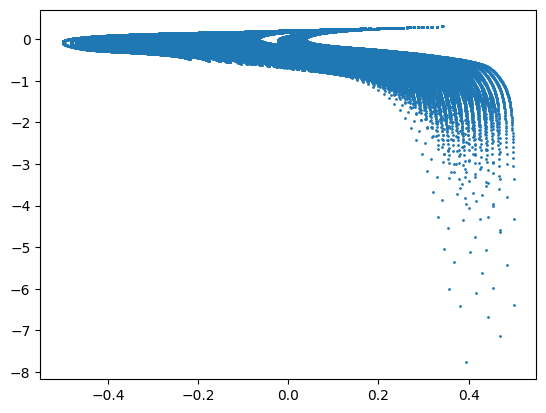

In [6]:
plt.scatter(extraVars, PV, s=1)
plt.show()

C:\Windows\Temp\ipykernel_29040\2842272902.py:37: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


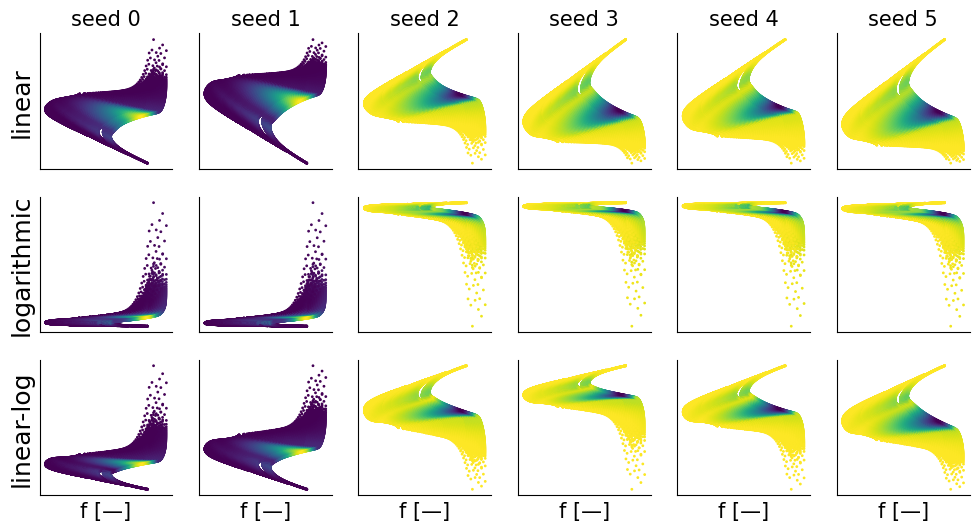

In [19]:
save = True
savePath = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-NOx/Experiments/Scaling QoIs/"
saveName = "2026-06-10 - 1PV flamelet - linLog QoIs"

scalingQoIs = ["lin", "log", "linLog"]
scalingLabels = ["linear", "logarithmic", "linear-log"]
nbr_seeds = 6

fig, axes = plt.subplots(len(scalingQoIs), nbr_seeds, figsize=(12, 6))

for idxScaling, scaling in enumerate(scalingQoIs):
    for seed in range(nbr_seeds):
        filename = f"Tr1_1PV_RMSprop_250_{scaling}_s{seed}-AE-date_03Jun2026-hour_18h03_Xu-flamelet-augm"

        loader = loadData(filename)
        extraVars, PV, PVsource = loader.getManifoldParameters(path_data, "flamelet")

        ax = axes[idxScaling, seed]
        ax.scatter(extraVars, PV, s=1, c = PVsource)
        ax.set_xticks([])
        ax.set_yticks([])

        if(seed == 0):
            ax.set_ylabel(scalingLabels[idxScaling], fontsize = 18)

        if(idxScaling == len(scalingQoIs)-1):
            ax.set_xlabel("f [\u2014]", fontsize = 15)
        elif(idxScaling == 0):
            ax.set_title(f"seed {seed}", fontsize = 15)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

if save:
    plt.savefig(savePath + saveName, dpi = 1000, bbox_inches = "tight")

fig.show()